In [4]:
import optuna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay



In [5]:
data = load_breast_cancer()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

In [6]:
def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    max_depth = trial.suggest_int("max_depth", 3, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)
    max_features = trial.suggest_categorical(
        "max_features",
        ["sqrt", "log2", None]
    )

    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )

    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    return f1_score(y_test, pred)

In [7]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

[I 2026-07-27 21:27:57,459] A new study created in memory with name: no-name-632af45e-4a0b-482f-875c-671fefc745ec
[I 2026-07-27 21:27:57,935] Trial 0 finished with value: 0.9583333333333334 and parameters: {'n_estimators': 151, 'max_depth': 5, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': None}. Best is trial 0 with value: 0.9583333333333334.
[I 2026-07-27 21:27:58,709] Trial 1 finished with value: 0.9655172413793104 and parameters: {'n_estimators': 300, 'max_depth': 8, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9655172413793104.
[I 2026-07-27 21:27:59,297] Trial 2 finished with value: 0.9583333333333334 and parameters: {'n_estimators': 207, 'max_depth': 15, 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': None}. Best is trial 1 with value: 0.9655172413793104.
[I 2026-07-27 21:27:59,954] Trial 3 finished with value: 0.9583333333333334 and parameters: {'n_estimators': 244, 'max_depth': 8, 'min_samp

In [8]:
print("Best Parameters:")
print(study.best_params)
print()
print("Best F1 Score:")
print(study.best_value)

Best Parameters:
{'n_estimators': 300, 'max_depth': 8, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt'}

Best F1 Score:
0.9655172413793104


In [9]:
best_model = RandomForestClassifier( **study.best_params, random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total nu

In [10]:
train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

In [11]:
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

train_f1 = f1_score(y_train, train_pred)
test_f1 = f1_score(y_test, test_pred)

print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")

print()

print(f"Train F1 Score : {train_f1:.4f}")
print(f"Test F1 Score  : {test_f1:.4f}")

Train Accuracy : 0.9868
Test Accuracy  : 0.9561

Train F1 Score : 0.9895
Test F1 Score  : 0.9655


In [12]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



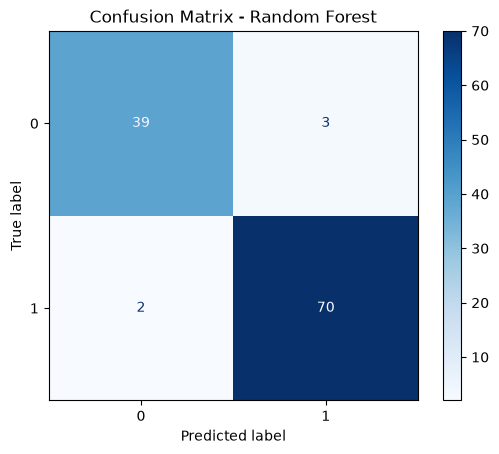

In [13]:
cm = confusion_matrix(y_test, test_pred)
ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_3236\3222002628.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


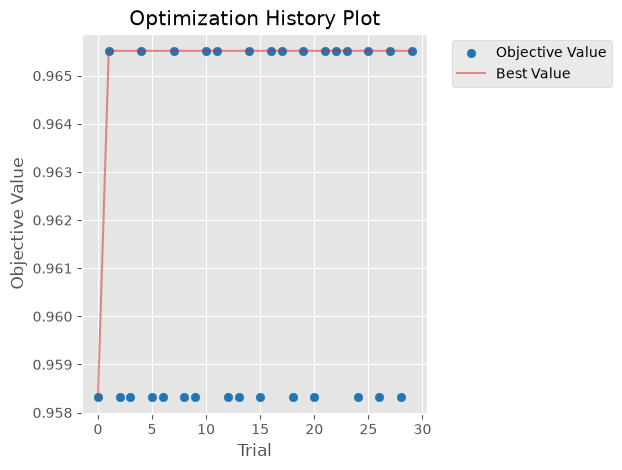

In [14]:
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_3236\429335526.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


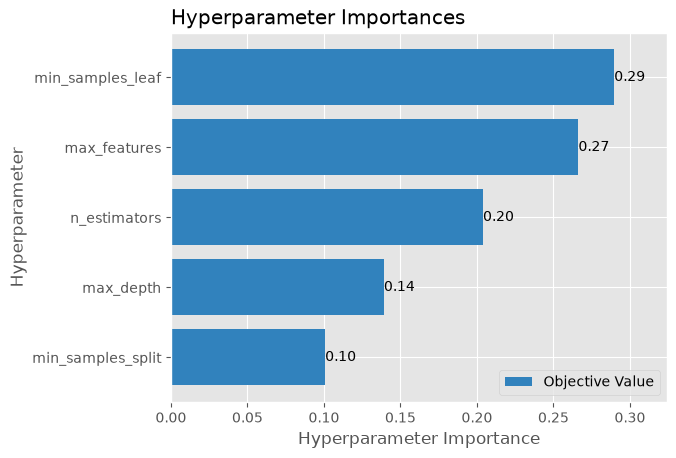

In [15]:
optuna.visualization.matplotlib.plot_param_importances(study)
plt.show()

# Summary

In this task, a Random Forest classifier was optimized using Optuna to automatically search for the best combination of hyperparameters. The objective was to maximize the F1 score on the test dataset by tuning several important parameters, including the number of trees, maximum tree depth, minimum samples required for splitting, minimum samples per leaf, and the number of features considered at each split.

After 30 optimization trials, Optuna selected the following hyperparameters:

- **n_estimators:** 300
- **max_depth:** 8
- **min_samples_split:** 2
- **min_samples_leaf:** 5
- **max_features:** sqrt

Using these optimized parameters, the Random Forest model achieved:

- **Train Accuracy:** 98.68%
- **Test Accuracy:** 95.61%
- **Train F1 Score:** 0.9895
- **Test F1 Score:** 0.9655

The confusion matrix shows that only **5 out of 114** test samples were misclassified. Although the training performance is slightly higher than the testing performance, the difference is relatively small, indicating only **mild overfitting**. Overall, the optimized Random Forest model provides strong classification performance and demonstrates the effectiveness of Optuna for automatic hyperparameter tuning.

**Conclusion:**

The Random Forest classifier achieved high classification performance after hyperparameter optimization. Optuna successfully identified a balanced set of parameters that reduced overfitting while maintaining excellent predictive accuracy. This demonstrates the value of automated hyperparameter optimization in improving machine learning models.

## Overall conclusion for all tasks

Among the four models, SVM with the RBF kernel achieved the best overall performance on the Breast Cancer Wisconsin dataset, obtaining the highest test accuracy (98.25%) and test F1 score (0.9861) while maintaining nearly identical training and testing performance. This indicates excellent generalization with no significant overfitting.

The Linear SVM also performed exceptionally well, suggesting that the dataset is almost linearly separable. The Decision Tree demonstrated how increasing model complexity can lead to overfitting, while the Random Forest, despite hyperparameter optimization with Optuna, achieved slightly lower test performance but still provided strong and reliable classification results. Overall, all four models achieved high performance, with the RBF SVM being the best choice for this dataset.